In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()

<IPython.core.display.Javascript object>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)


<IPython.core.display.Javascript object>

C:\Users\yshel\AppData\Local\Temp\ipykernel_7984\883733217.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [9]:
df = pd.get_dummies(df, drop_first=True)


<IPython.core.display.Javascript object>

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


<IPython.core.display.Javascript object>

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


<IPython.core.display.Javascript object>

In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


<IPython.core.display.Javascript object>

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8197303051809794
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



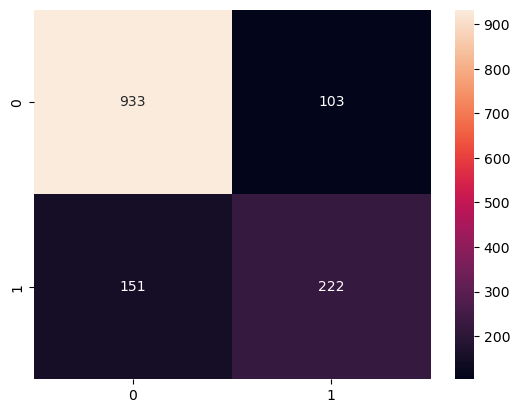

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()


In [19]:
import joblib
joblib.dump(model, "../model/churn_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

In [31]:
# Reload and preprocess for extended app features
df_raw = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw['TotalCharges'].fillna(df_raw['TotalCharges'].median(), inplace=True)
df_raw.drop('customerID', axis=1, inplace=True)
df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})

# Map categoricals
df_raw['Contract'] = df_raw['Contract'].map({"Month-to-month":0, "One year":1, "Two year":2})
df_raw['PaymentMethod'] = df_raw['PaymentMethod'].map({"Electronic check":0,"Mailed check":1,"Bank transfer (automatic)":2,"Credit card (automatic)":3})
df_raw['gender'] = df_raw['gender'].map({"Male":0,"Female":1})
df_raw['PaperlessBilling'] = df_raw['PaperlessBilling'].map({"No":0,"Yes":1})
df_raw['InternetService'] = df_raw['InternetService'].map({"DSL":0,"Fiber optic":1,"No":2})
df_raw['Partner'] = df_raw['Partner'].map({"No":0,"Yes":1})
df_raw['Dependents'] = df_raw['Dependents'].map({"No":0,"Yes":1})
df_raw['PhoneService'] = df_raw['PhoneService'].map({"No":0,"Yes":1})
df_raw['MultipleLines'] = df_raw['MultipleLines'].map({"No":0,"No phone service":1,"Yes":2})

# Create total_services
df_raw['total_services'] = (df_raw['OnlineSecurity'] == 'Yes').astype(int) + \
                          (df_raw['TechSupport'] == 'Yes').astype(int) + \
                          (df_raw['DeviceProtection'] == 'Yes').astype(int) + \
                          (df_raw['StreamingTV'] == 'Yes').astype(int) + \
                          (df_raw['StreamingMovies'] == 'Yes').astype(int)

# Select extended features
features_app = ['tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'SeniorCitizen', 'gender', 'PaperlessBilling', 'InternetService', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'total_services']
X_app = df_raw[features_app]
y_app = df_raw['Churn']

X_train_app, X_test_app, y_train_app, y_test_app = train_test_split(
    X_app, y_app, test_size=0.2, random_state=42
)

scaler_app = StandardScaler()
X_train_app_scaled = scaler_app.fit_transform(X_train_app)
X_test_app_scaled = scaler_app.transform(X_test_app)

rf_model_app = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_app.fit(X_train_app_scaled, y_train_app)

y_pred_rf = rf_model_app.predict(X_test_app_scaled)
print("Extended RF App Model Accuracy:", accuracy_score(y_test_app, y_pred_rf))
print(classification_report(y_test_app, y_pred_rf))

# Save extended model
import pickle
with open("../model/extended_rf_app_churn_model.pkl", "wb") as f:
    pickle.dump(rf_model_app, f)
with open("../model/extended_app_scaler.pkl", "wb") as f:
    pickle.dump(scaler_app, f)

C:\Users\yshel\AppData\Local\Temp\ipykernel_7984\448960958.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_raw['TotalCharges'].fillna(df_raw['TotalCharges'].median(), inplace=True)


Extended RF App Model Accuracy: 0.7885024840312278
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

